In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [2]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [ ]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [ ]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)


# Normalization for visualization
h5_rna_union.layers['log1p_counts'] = np.log1p(h5_rna_union.X)
h5_rna_union.layers['cpm'] = sc.pp.normalize_total(h5_rna_union, target_sum=1e4, inplace=False)['X']
h5_rna_union.layers['log1p_cpm'] = np.log1p(h5_rna_union.layers['cpm'])

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
SCVI_LATENT_KEY = "RNA_scVI_unionBC"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_unionBC"


vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.5)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

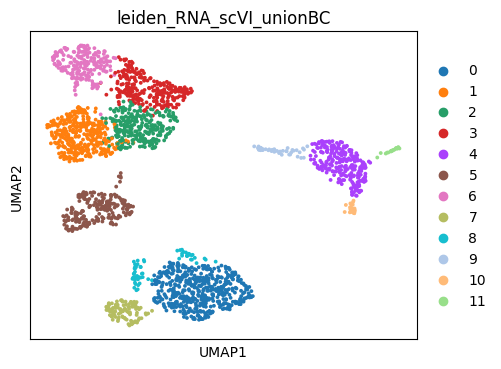

In [8]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI_unionBC'], wspace=0.2, size=30, ncols=3)

In [9]:
col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_cell_info[col])

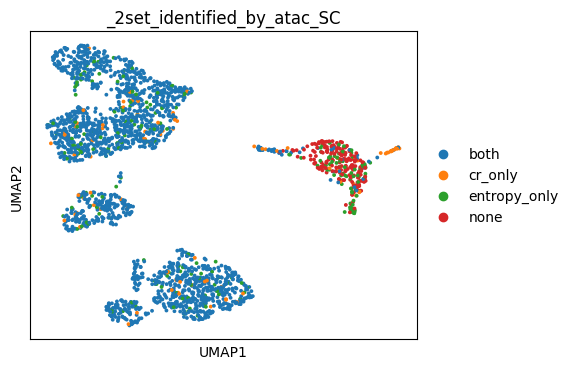

In [10]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['_2set_identified_by_atac_SC'], wspace=0.2, size=30, ncols=3)

In [ ]:
h5_rna_union.var_names_make_unique("-")

rna_clusters = h5_rna_union.obs['leiden_RNA_scVI_unionBC'].unique().tolist()


DE_rna_clusters = {}
for cluster in rna_clusters:
    DE_rna_clusters[cluster] =  vae.differential_expression(h5_rna_union, groupby='leiden_RNA_scVI_unionBC', group1=cluster)



# save DE results
DE_dir = os.path.join(Union_cell_subdir, 'RNAcluster_DE_results')
if not os.path.exists(DE_dir):
    os.makedirs(DE_dir)

save_cols = ['lfc_mean', 'neg_log10_pval', 'is_de_fdr_0.05', 'proba_de',  'proba_not_de', 'comparison', 'raw_mean1', 'raw_mean2', 'group1', 'group2']
for c in rna_clusters:
    DE_rna_clusters[c]['neg_log10_pval'] = -np.log10(DE_rna_clusters[c]['proba_not_de'])
    _ = DE_rna_clusters[c].loc[(DE_rna_clusters[c]['is_de_fdr_0.05']) & (DE_rna_clusters[c]['lfc_mean'] > 0.) ].sort_values('lfc_mean', ascending=False)
    _[save_cols].to_csv(os.path.join(DE_dir, f'RNA_c_{c}_Up.tsv'), sep='\t')
    _ = DE_rna_clusters[c].loc[(DE_rna_clusters[c]['is_de_fdr_0.05']) & (DE_rna_clusters[c]['lfc_mean'] < 0.) ].sort_values('lfc_mean', ascending=True)
    _[save_cols].to_csv(os.path.join(DE_dir, f'RNA_c_{c}_Down.tsv'), sep='\t')


DE...: 100%|██████████| 1/1 [00:03<00:00,  3.15s/it]


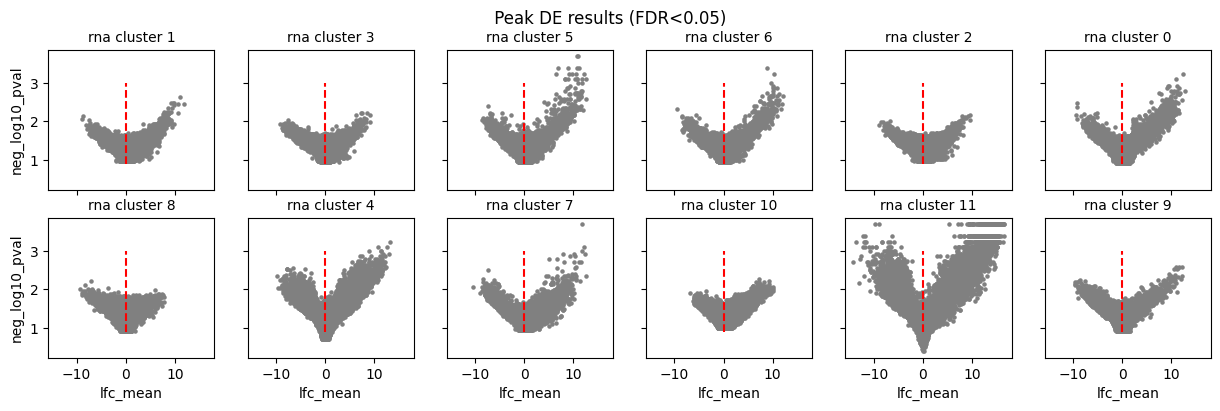

In [201]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(rna_clusters):
    ax = axes[i]
    DE_rna_clusters[cluster].loc[(DE_rna_clusters[cluster]['is_de_fdr_0.05']) ].plot.scatter(x='lfc_mean', y='neg_log10_pval', ax=ax, title=f'rna cluster {cluster}', s = 5, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=3, linestyle='--')
    ax.set_title(f'rna cluster {cluster}', fontsize=10)

plt.suptitle(' Peak DE results (FDR<0.05) ', fontsize=12)
plt.show()

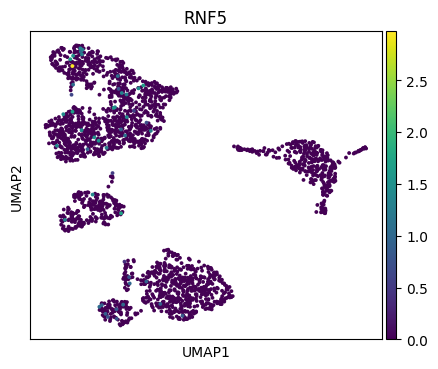

In [248]:
genes = ['ARFGEF3', 'MS4A3', 'SERPINB10', ]
genes = ['CELA2A', 'NGF', 'TLR4', 'SCARB1', 'TREM2', ]
genes = ['RNF5']
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=genes, wspace=0.2, size=30, ncols=3, layer='log1p_cpm')

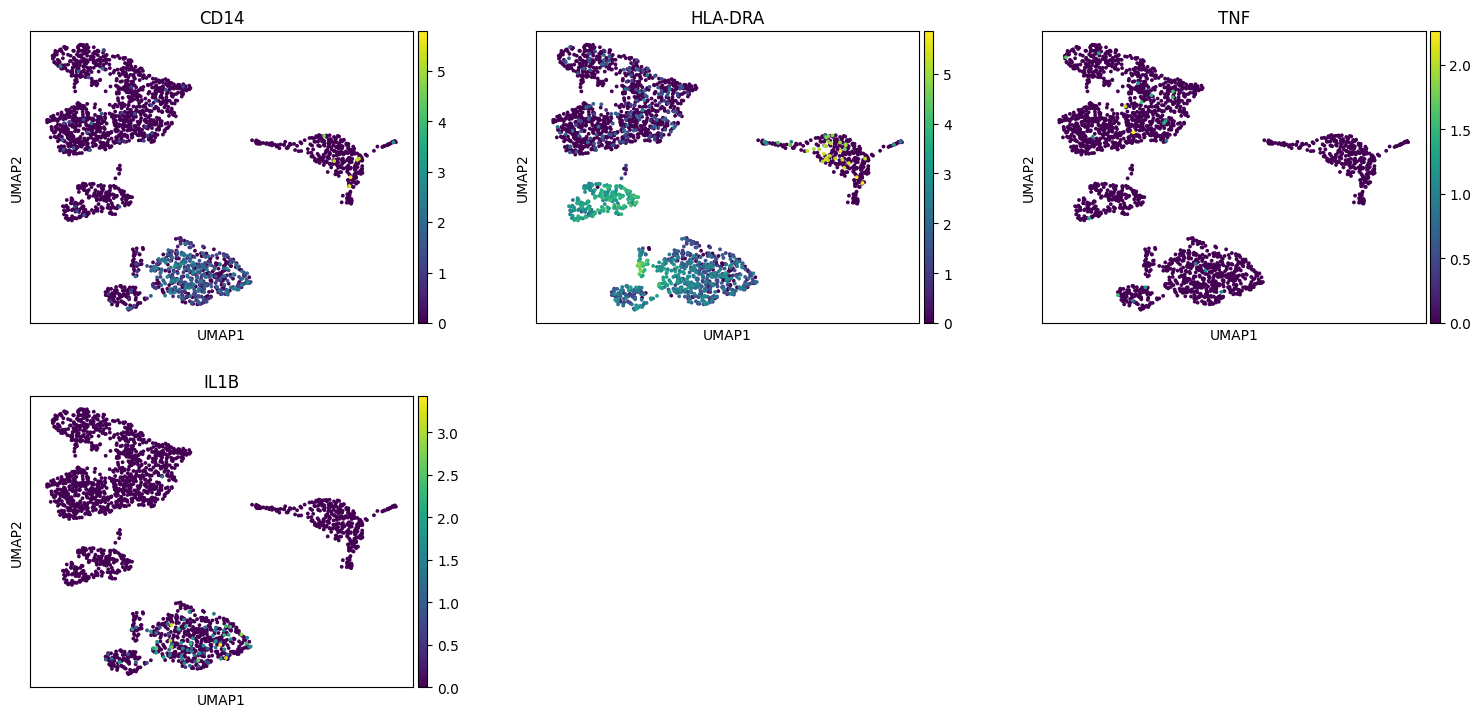

In [242]:

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['CD14', 'HLA-DRA', 'TNF', 'IL1B', ], wspace=0.2, size=30, ncols=3, layer='log1p_cpm')

In [245]:
cluster='c4_entropy_unique'
h5_rna_union.obs['c4_entropy_unique'] = (h5_rna_union.obs['leiden_RNA_scVI_unionBC'] == '4') &  (h5_rna_union.obs['_2set_identified_by_atac_SC'] == 'entropy_only') 
DE_rna_clusters[cluster] =  vae.differential_expression(h5_rna_union, groupby='c4_entropy_unique', group1=True)
DE_rna_clusters[cluster]['neg_log10_pval'] = -np.log10(DE_rna_clusters[cluster]['proba_not_de'])



save_cols = ['lfc_mean', 'neg_log10_pval', 'is_de_fdr_0.05', 'proba_de',  'proba_not_de', 'comparison', 'raw_mean1', 'raw_mean2', 'group1', 'group2']
for c in ['c4_entropy_unique']:
    _ = DE_rna_clusters[c].loc[(DE_rna_clusters[c]['is_de_fdr_0.05']) & (DE_rna_clusters[c]['lfc_mean'] > 0.) ].sort_values('lfc_mean', ascending=False)
    _[save_cols].to_csv(os.path.join(DE_dir, f'RNA_c_{c}_Up.tsv'), sep='\t')
    _ = DE_rna_clusters[c].loc[(DE_rna_clusters[c]['is_de_fdr_0.05']) & (DE_rna_clusters[c]['lfc_mean'] < 0.) ].sort_values('lfc_mean', ascending=True)
    _[save_cols].to_csv(os.path.join(DE_dir, f'RNA_c_{c}_Down.tsv'), sep='\t')


h5_rna_union.obs['c4_entropy_unique'].value_counts()


DE...: 100%|██████████| 1/1 [00:03<00:00,  3.15s/it]


c4_entropy_unique
False    2323
True       58
Name: count, dtype: int64

# Now only subset BCs for comparing SADE/entropy vs CellRanger and analyze ATAC signals

In [106]:
cmp_SC_subdir=  os.path.join(entropy_dir, '_cell_calling_comparison', 'cmp_SC')

In [11]:
h5_rna_SC = h5_rna_union[h5_rna_union.obs['_2set_identified_by_atac_SC'] != 'none'].copy()

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
h5_rna_SC.obs.head(2)

,rna_barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI_unionBC,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,Entropy,DNA_debris
AAACAGCCAGGCTACT-1,AAACAGCCAGGCTACT,ACAGCGGGTTTGTAGC,3931.0,8.276903,1772,519.0,13.202747,0,0,1,3390,True,True,True,both,both,True,0.130478,NO
AAACATGCAAGGATTA-1,AAACATGCAAGGATTA,CATTTAGGTAACAGCA,3566.0,8.179481,1689,401.0,11.245092,0,0,3,11169,True,True,True,both,both,True,0.197080,NO


In [13]:
entropy_peak_dir = os.path.join(Union_cell_subdir, "Entropy_cells_peaks")
atac_entropy_peak_pic = os.path.join(entropy_peak_dir, "DownstreamReanalysis", "bc_peak_pic_count.h5ad" )
h5_atac_entropy_peak = sc.read_h5ad(atac_entropy_peak_pic)
h5_atac_entropy_peak.obs['atac_barcodes'] = h5_atac_entropy_peak.obs['barcodes'].map(lambda x: x.split("-")[0])


In [14]:
h5_atac_entropy_peak

AnnData object with n_obs × n_vars = 2384 × 62565
    obs: 'barcodes', 'atac_barcodes'
    var: 'peak'

In [15]:
h5_atac_entropy_peak_SC = h5_atac_entropy_peak[h5_atac_entropy_peak.obs['atac_barcodes'].isin(h5_rna_SC.obs['atac_barcodes'])].copy()

In [16]:

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# %%
PEAKVI_LATENT_KEY = "X_peakvi_cmpSC"
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_cmpSC"

#%%
# filter regions with less than 3% of the cells
# print("# regions before filtering:", peak_count_adata.shape[-1])

# sc.pp.filter_genes(peak_count_adata, min_cells=10)
# print("# regions after filtering:", peak_count_adata.shape[-1])

# Let's Use All the identified peaks for comarison (since entropy approach already has more peaks)
# train on h5_atac_entropy_peak_SC
scvi.model.PEAKVI.setup_anndata(h5_atac_entropy_peak_SC)
peak_model = scvi.model.PEAKVI(h5_atac_entropy_peak_SC)
peak_model.train()
# #save model
# peak_model.save(des_model_dir, overwrite=True)

# #save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_entropy_peak_SC.obsm[PEAKVI_LATENT_KEY] = latent
resolution = 0.4
sc.pp.neighbors(h5_atac_entropy_peak_SC, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_entropy_peak_SC, min_dist=0.5)
sc.tl.leiden(h5_atac_entropy_peak_SC, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Last run with scvi-tools version: 1.2.0


/tmp/ipykernel_3420593/1181022805.py:19: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider incr

Epoch 197/500:  39%|███▉      | 197/500 [01:54<02:56,  1.72it/s, v_num=1, train_loss_step=3.13e+7, train_loss_epoch=1.7e+8] 
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 12262.570. Signaling Trainer to stop.


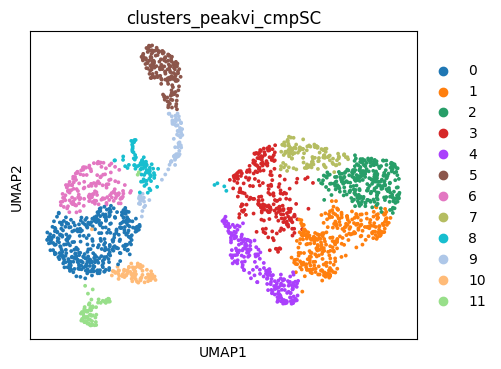

In [17]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_entropy_peak_SC, color=['clusters_peakvi_cmpSC'], wspace=0.2, size=30, ncols=3)

In [250]:
h5_atac_entropy_peak_SC.obs['clusters_peakvi_cmpSC'].value_counts()

clusters_peakvi_cmpSC
0     379
1     315
2     289
3     240
4     210
5     167
6     161
7     117
8      83
9      81
10     79
11     71
Name: count, dtype: int64

In [21]:
col_list = ['total_fragments', 
        '_2set_identified_by_atac_SC',
       'rna_pass_CR', 
       'Entropy', 'DNA_debris'] + \
           ['leiden_RNA_scVI_unionBC'] + \
    ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts']
for col in col_list:
    h5_atac_entropy_peak_SC.obs[col] = h5_atac_entropy_peak_SC.obs['atac_barcodes'].map(h5_rna_SC.obs.set_index('atac_barcodes')[col])
    
h5_atac_entropy_peak_SC.obs['log_total_fragments'] = np.log10(h5_atac_entropy_peak_SC.obs['total_fragments'] )

In [109]:
save_cluster_subdir= os.path.join(cmp_SC_subdir, "entropy_peak_atac_cluster")
if not os.path.exists(save_cluster_subdir):
    os.makedirs(save_cluster_subdir)
h5_atac_entropy_peak_SC.obs.to_csv(os.path.join(save_cluster_subdir, "cmp_SC_entropypeakatac_cluster.csv"), sep='\t', index=False)

h5_atac_entropy_peak_SC

AnnData object with n_obs × n_vars = 2192 × 62565
    obs: 'barcodes', 'atac_barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi_cmpSC', 'total_fragments', '_2set_identified_by_atac_SC', 'rna_pass_CR', 'Entropy', 'DNA_debris', 'MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'log_total_fragments', 'leiden_RNA_scVI_unionBC'
    var: 'peak'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'clusters_peakvi_cmpSC', 'clusters_peakvi_cmpSC_colors', 'leiden_RNA_scVI_unionBC_colors', 'DNA_debris_colors', '_2set_identified_by_atac_SC_colors'
    obsm: 'X_peakvi_cmpSC', 'X_umap'
    obsp: 'distances', 'connectivities'

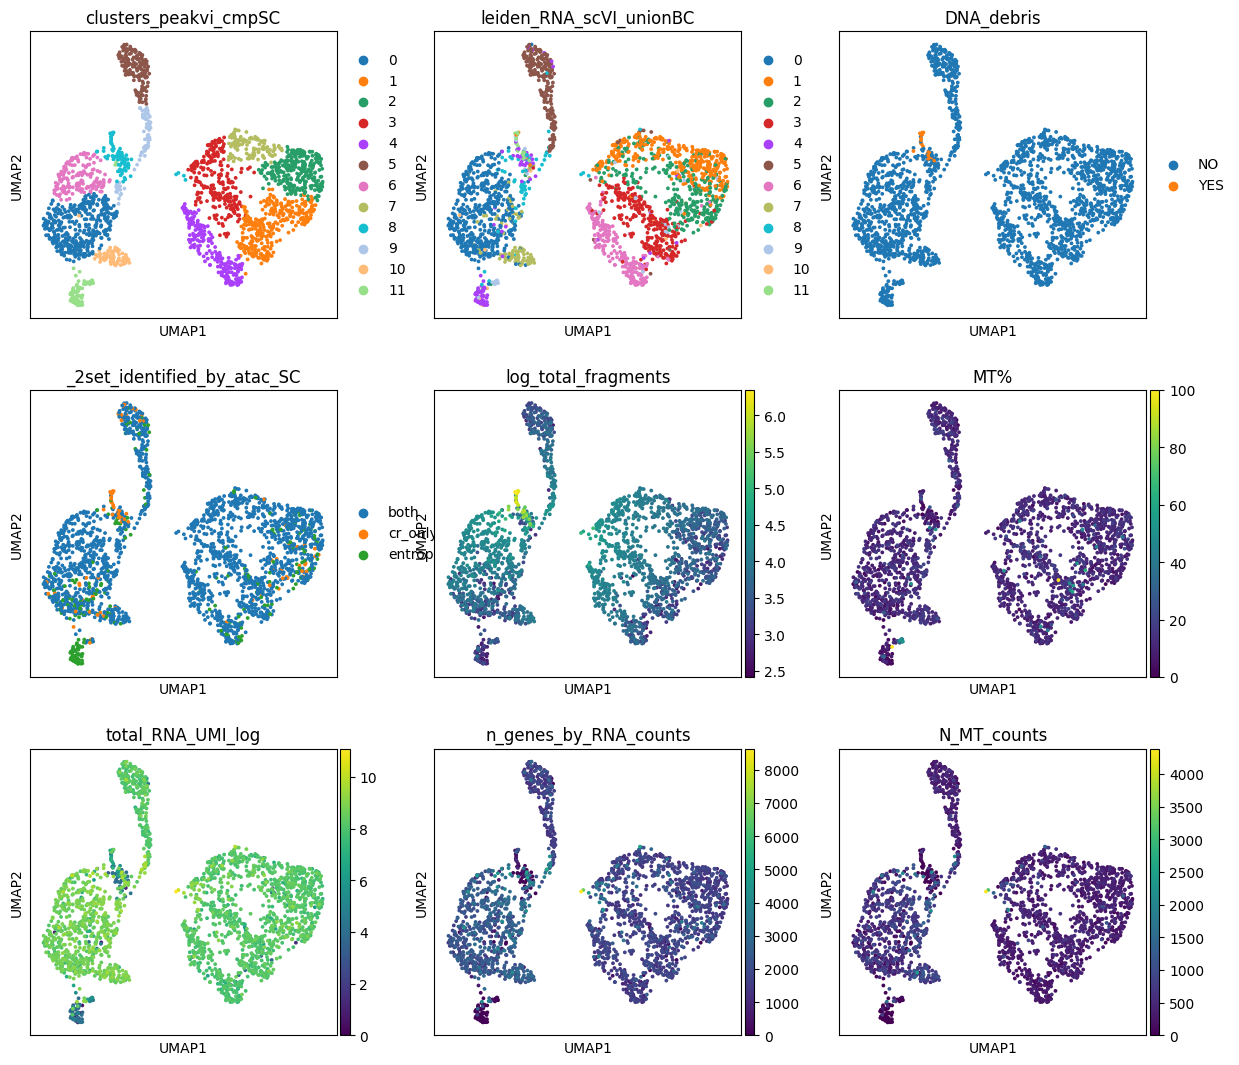

In [25]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_atac_entropy_peak_SC, color=['clusters_peakvi_cmpSC', ] + 
               ['leiden_RNA_scVI_unionBC', 'DNA_debris', ] + ['_2set_identified_by_atac_SC', 'log_total_fragments'] + 
               ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts']  , wspace=0.2, size=30, ncols=3)

## Get DARs 

In [26]:
atac_cluster_DARs = {}
cluster_list = h5_atac_entropy_peak_SC.obs['clusters_peakvi_cmpSC'].unique()
for cluster in cluster_list:
    print(f" DARs on atac-cluster {cluster}")
    atac_cluster_DARs[cluster] = peak_model.differential_accessibility(
        groupby="clusters_peakvi_cmpSC", group1=cluster,  two_sided=True
    )

 DARs on atac-cluster 1
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.63s/it]
 DARs on atac-cluster 11
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.39s/it]
 DARs on atac-cluster 5
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.61s/it]
 DARs on atac-cluster 9
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.52s/it]
 DARs on atac-cluster 6
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.61s/it]
 DARs on atac-cluster 0
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.39s/it]
 DARs on atac-cluster 8
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.29s/it]
 DARs on atac-cluster 3
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.25s/it]
 DARs on atac-cluster 2
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.20s/it]
 DARs on atac-cluster 7
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.31s/it]
 DARs on atac-cluster 4
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.37s/it]
 DARs on atac-cluster 10
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.44s/it]


In [ ]:
## manually change effect-size sign 
for cluster in atac_cluster_DARs.keys():
    atac_cluster_DARs[cluster]['effect_size_correct_sign'] = -atac_cluster_DARs[cluster]['effect_size']


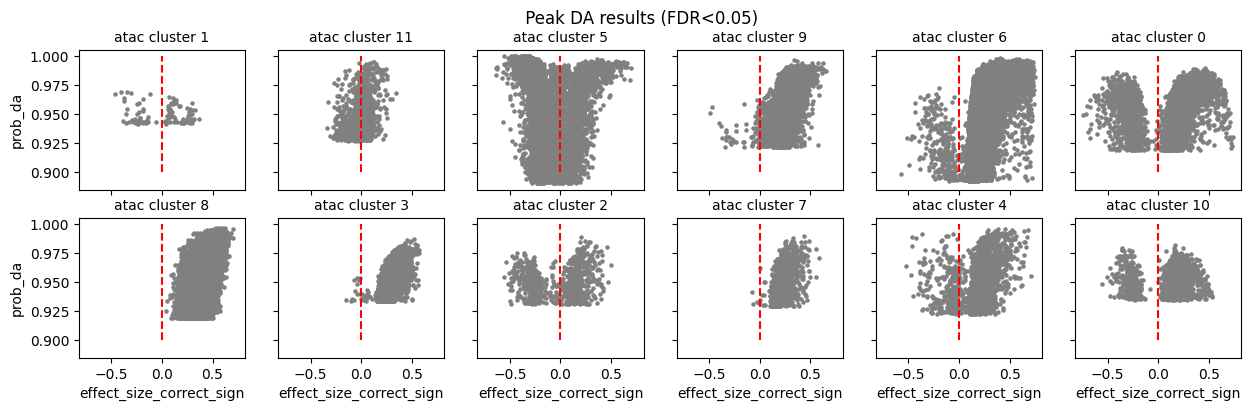

In [105]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) ].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 5, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(' Peak DA results (FDR<0.05) ', fontsize=12)
plt.show()

## Check peaks 

In [29]:
peaks_columns_set = ['chrom', 'chromStart', 'chromEnd', 'peak_name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
cCREs_annot_columns_set = ['cCREs' + col for col in ['chr', 'Start', 'End', 'name', 'name2', 'category', 'overlap_bp']]

entropy_peak_set_file = os.path.join(entropy_peak_dir, "peaks.bed")
entropy_peak_set = pd.read_csv(entropy_peak_set_file, sep='\t', header=None)


cCRES_annot_entropy_peak_file = os.path.join(entropy_peak_dir, "cCRE_annotation", 'cCRE_annot_peaks.bed')
cCRES_annot_entropy_peak = pd.read_csv(cCRES_annot_entropy_peak_file, sep='\t', header=None)


entropy_peak_set.columns = peaks_columns_set
cCRES_annot_entropy_peak.columns = peaks_columns_set + cCREs_annot_columns_set
cCRES_annot_entropy_peak['peak_pos'] = cCRES_annot_entropy_peak['chrom'] + ":" + cCRES_annot_entropy_peak['chromStart'].astype(str) + "-" + cCRES_annot_entropy_peak['chromEnd'].astype(str)

In [41]:
cCRES_annot = cCRES_annot_entropy_peak.loc[cCRES_annot_entropy_peak['cCREsoverlap_bp'] > 0].copy()

print("Number of peaks ", cCRES_annot_entropy_peak.shape[0])
print("Number of peaks overlapping cCREs ", cCRES_annot.shape[0])

Number of peaks  146808
Number of peaks overlapping cCREs  144660


In [42]:
cCRES_annot_entropy_peak.loc[cCRES_annot_entropy_peak['cCREsoverlap_bp'] == 0].head(2)

,chrom,chromStart,chromEnd,peak_name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREschr,cCREsStart,cCREsEnd,cCREsname,cCREsname2,cCREscategory,cCREsoverlap_bp,peak_pos
5,chr1,857965,858226,peak_36,1000,.,311.858093,4.013170,-1,177,.,-1,-1,.,.,.,0,chr1:857965-858226
55,chr1,1009233,1009537,peak_52,1000,.,347.502289,3.726698,-1,147,.,-1,-1,.,.,.,0,chr1:1009233-1009537


Text(0, 0.5, 'Frequency')

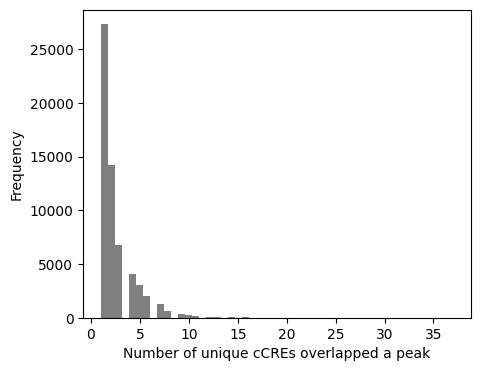

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
_ = ax.hist( cCRES_annot['peak_name'].value_counts(),  bins=50, color='grey')
ax.set_xlabel("Number of unique cCREs overlapped a peak")
ax.set_ylabel("Frequency")

In [49]:
# annotate the peaks with cCREs annotation
for cluster in atac_cluster_DARs.keys():
    atac_cluster_DARs[cluster]['peak_pos'] = h5_atac_entropy_peak_SC.var['peak'].loc[atac_cluster_DARs[cluster].index]
    
    
cCREs_catogories = cCRES_annot['cCREscategory'].unique()
print("unique cCREs_catogories: ", cCREs_catogories)

for cat in cCREs_catogories:
    print(f"Annotating peaks with cCRE category {cat}")
    for cluster in atac_cluster_DARs.keys():
        atac_cluster_DARs[cluster][f'overlap_{cat}'] = atac_cluster_DARs[cluster]['peak_pos'].isin(cCRES_annot.loc[cCRES_annot['cCREscategory'] == cat, 'peak_pos'])

unique cCREs_catogories:  ['PLS' 'pELS,CTCF-bound' 'PLS,CTCF-bound' 'dELS'
 'DNase-H3K4me3,CTCF-bound' 'dELS,CTCF-bound' 'pELS'
 'CTCF-only,CTCF-bound' 'DNase-H3K4me3']
Annotating peaks with cCRE category PLS
Annotating peaks with cCRE category pELS,CTCF-bound
Annotating peaks with cCRE category PLS,CTCF-bound
Annotating peaks with cCRE category dELS
Annotating peaks with cCRE category DNase-H3K4me3,CTCF-bound
Annotating peaks with cCRE category dELS,CTCF-bound
Annotating peaks with cCRE category pELS
Annotating peaks with cCRE category CTCF-only,CTCF-bound
Annotating peaks with cCRE category DNase-H3K4me3


### Plot DARs in cCREs catogories

In [ ]:
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='pink', markersize=20, label='DNase-H3K4me3,CTCF-bound'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=20, label='pELS,CTCF-bound'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor='brown', markersize=20, label='PLS,CTCF-bound'),
           Line2D([0], [0], marker='o', color='w    ', markerfacecolor='slateblue', markersize=20, label='CTCF-only,CTCF-bound'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=20, label='dELS,CTCF-bound')]

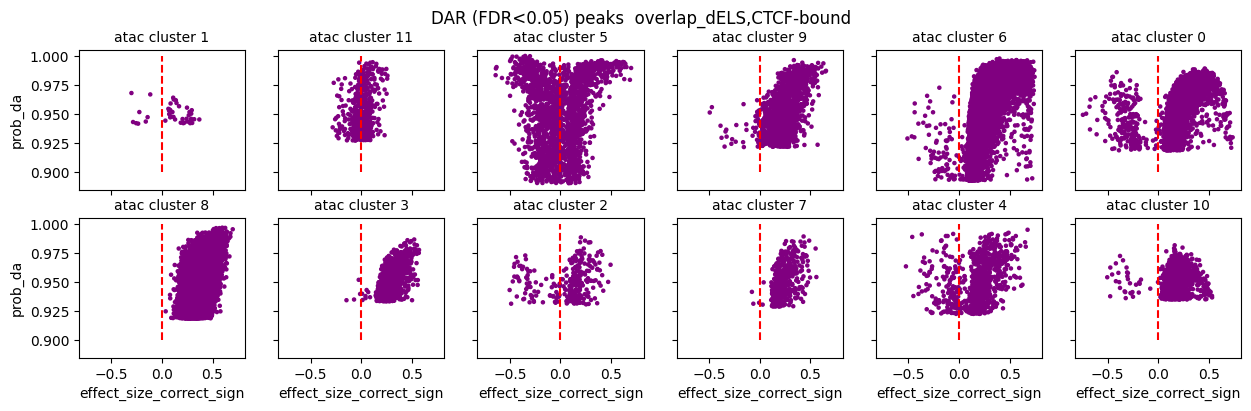

In [ ]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'purple', False: 'grey'}
show_cat = 'overlap_' + 'dELS,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 5, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

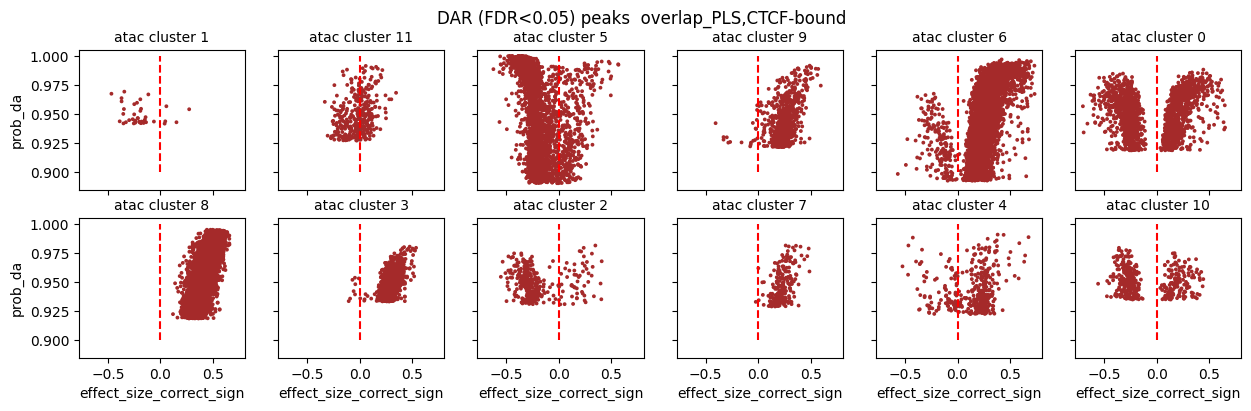

In [97]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'brown', False: 'grey'}
show_cat = 'overlap_' + 'PLS,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

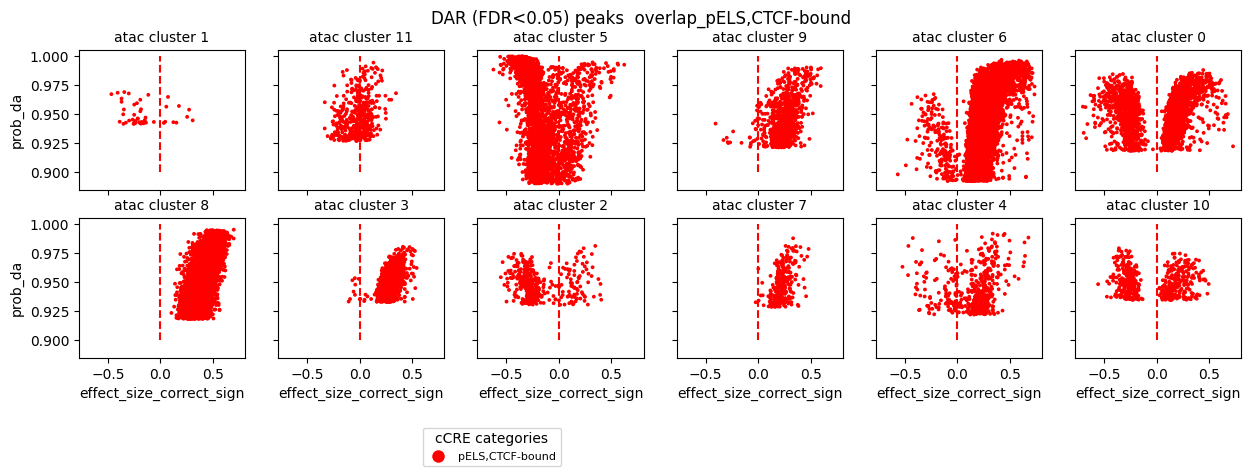

In [98]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'red', False: 'grey'}
show_cat = 'overlap_' + 'pELS,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='pELS,CTCF-bound')]
fig.legend(handles=handles, loc='upper right', title='cCRE categories', fontsize=8, bbox_to_anchor=(0.45, -0.05))
plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

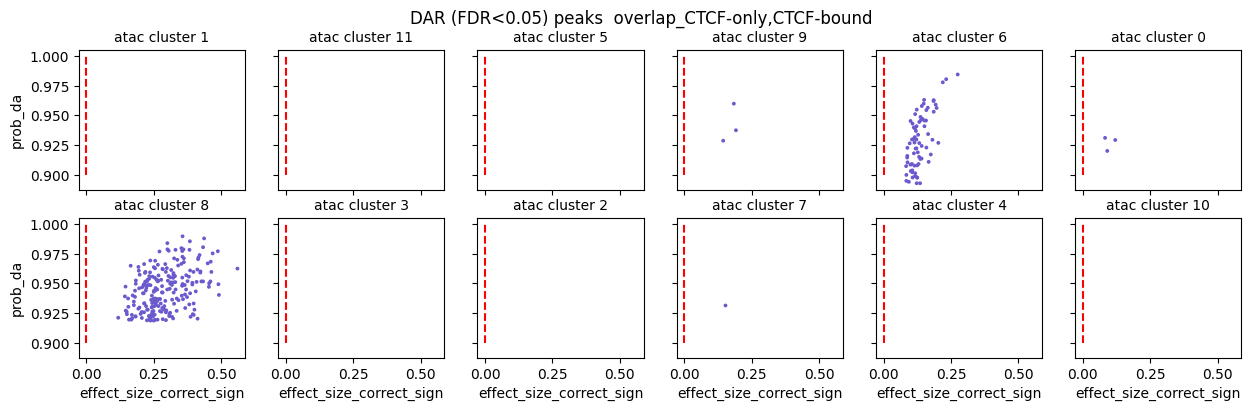

In [ ]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'slateblue', False: 'grey'}
show_cat = 'overlap_' + 'CTCF-only,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

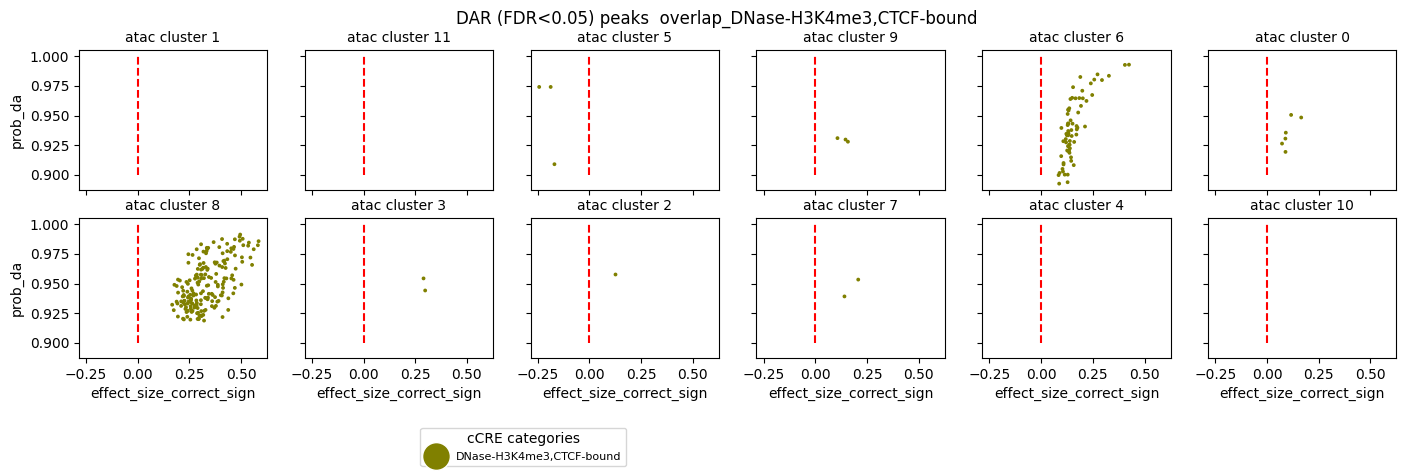

In [ ]:
fig, axes = plt.subplots(2, 6,  figsize=(17,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'olive', False: 'grey'}
show_cat = 'overlap_' + 'DNase-H3K4me3,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

# add a single legend for the whole figure

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='olive', markersize=20, label='DNase-H3K4me3,CTCF-bound')]
fig.legend(handles=handles, loc='upper right', title='cCRE categories', fontsize=8, bbox_to_anchor=(0.45, -0.05))

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

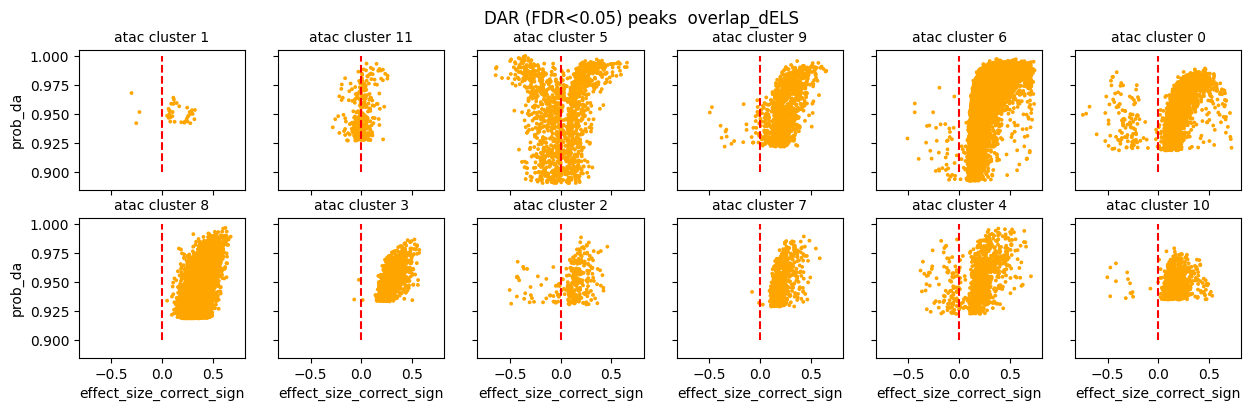

In [100]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'orange', False: 'grey'}
show_cat = 'overlap_' + 'dELS'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

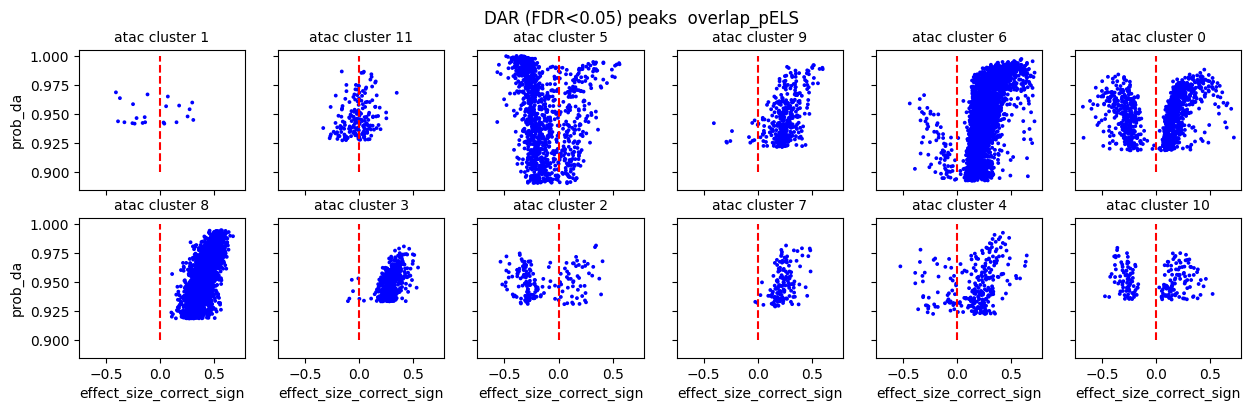

In [101]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'blue', False: 'grey'}
show_cat = 'overlap_' + 'pELS'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

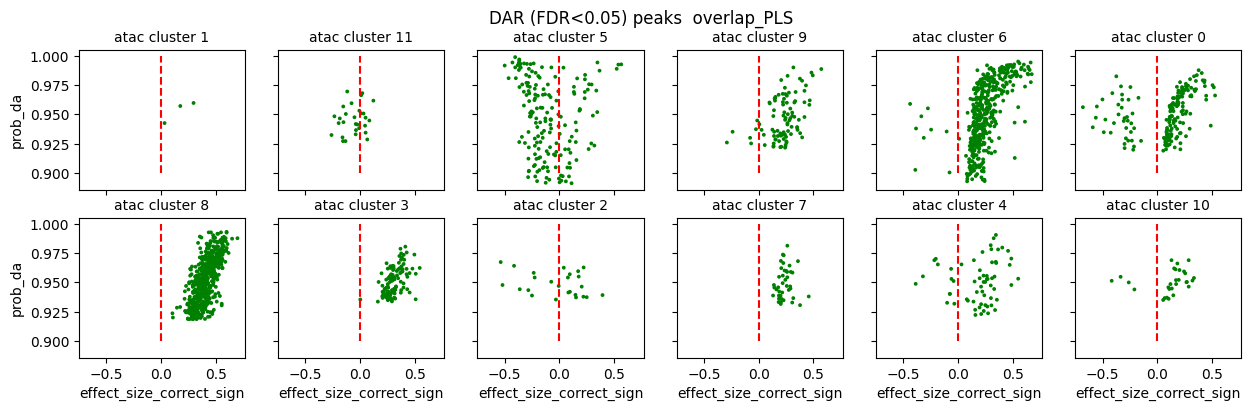

In [102]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'green', False: 'grey'}
show_cat = 'overlap_' + 'PLS'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

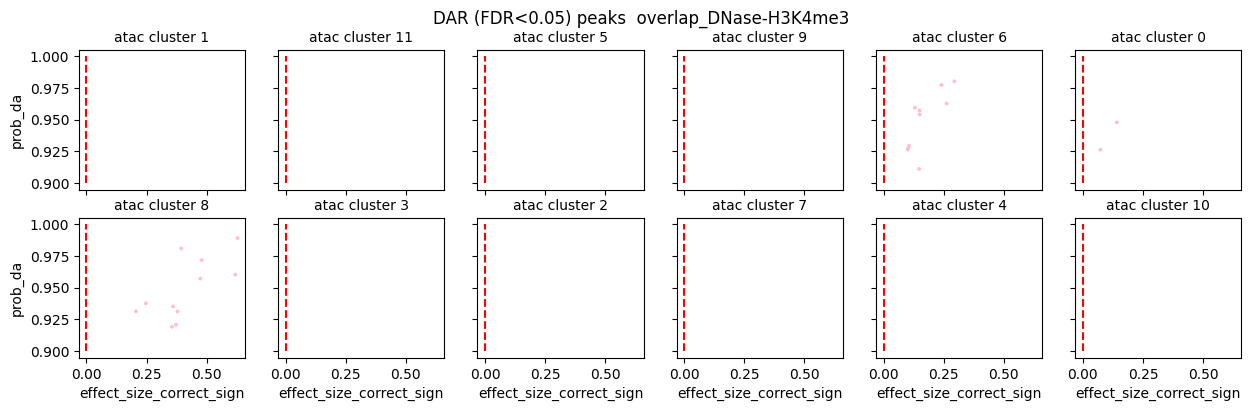

In [103]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'pink', False: 'grey'}
show_cat = 'overlap_' + 'DNase-H3K4me3'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

In [121]:
cluster = '11'
atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster]['effect_size'] < 0.) ].sort_values('effect_size', ascending=True).head(20)

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2,effect_size_correct_sign,peak_pos,overlap_PLS,"overlap_pELS,CTCF-bound","overlap_PLS,CTCF-bound",overlap_dELS,"overlap_DNase-H3K4me3,CTCF-bound","overlap_dELS,CTCF-bound",overlap_pELS,"overlap_CTCF-only,CTCF-bound",overlap_DNase-H3K4me3
59627,0.9682,True,3.415972,-0.346567,0.147811,0.773934,0.427368,0.056338,0.204149,0.346567,chr9:107489383-107490925,False,True,True,False,False,False,True,False,False
22828,0.9626,True,3.247967,-0.301584,0.193484,0.844297,0.542713,0.042254,0.235738,0.301584,chr16:66515720-66517807,False,True,True,False,False,False,False,False,False
20447,0.9626,True,3.247967,-0.281910,0.158715,0.797276,0.515366,0.070423,0.229137,0.281910,chr15:75042763-75044351,False,True,True,False,False,False,False,False,False
28656,0.9830,True,4.057395,-0.259790,0.131250,0.666266,0.406476,0.042254,0.173503,0.259790,chr19:2167851-2169486,False,False,False,True,False,True,False,False,False
54796,0.9804,True,3.912431,-0.257175,0.055993,0.580356,0.323181,0.084507,0.140500,0.257175,chr7:101717085-101718784,False,False,False,True,False,True,False,False,False
9209,0.9674,True,3.390299,-0.251071,0.247113,0.810825,0.559754,0.014085,0.261198,0.251071,chr10:128063707-128065568,False,False,False,False,False,True,False,False,False
57272,0.9462,True,2.867180,-0.250832,0.243813,0.840951,0.590118,0.014085,0.257897,0.250832,chr8:96644836-96646131,False,True,True,False,False,False,True,False,False
3785,0.9512,True,2.969994,-0.248686,0.237624,0.798952,0.550266,0.000000,0.237624,0.248686,chr1:151944334-151946736,False,True,True,False,False,False,True,False,False
49670,0.9888,True,4.480577,-0.248662,0.174506,0.615027,0.366366,0.014085,0.188590,0.248662,chr6:13302418-13303434,False,False,False,False,False,True,False,False,False
29945,0.9660,True,3.346803,-0.245907,0.203266,0.749524,0.503617,0.014085,0.217350,0.245907,chr19:18172742-18174639,False,True,True,False,False,False,False,False,False


In [ ]:
(atac_cluster_DARs['11']['effect_size']) > 0

Entropy_peak_cluster: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
median_entropy: [-0.698 -0.896 -0.905 -0.731 -0.778 -0.933 -0.617 -0.791 -0.541 -0.704
 -0.783 -1.027]
mean_entropy: [-0.726 -0.927 -0.915 -0.726 -0.792 -0.969 -0.6   -0.809 -0.563 -0.696
 -0.78  -0.944]


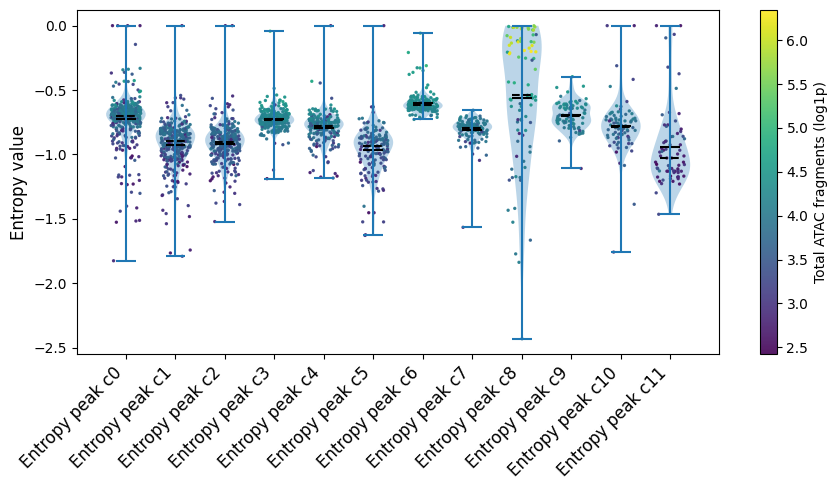

In [ ]:
x_positions = range(12)  #also used as RNA_cluster id in string
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [np.log10(h5_atac_entropy_peak_SC.obs.loc[h5_atac_entropy_peak_SC.obs['clusters_peakvi_cmpSC'] == str(c), 'Entropy'].fillna(1)) for c in x_positions]
total_atac_fragments = [h5_atac_entropy_peak_SC.obs.loc[h5_atac_entropy_peak_SC.obs['clusters_peakvi_cmpSC'] == str(c), 'log_total_fragments'] for c in x_positions]
color_range = (h5_atac_entropy_peak_SC.obs['log_total_fragments'].min(), h5_atac_entropy_peak_SC.obs['log_total_fragments'].max())
for i, v in enumerate(entropy_value):
    if len(v) ==0:
        entropy_value[i] = np.array([np.inf])  # to avoid error in violin plot when no data point exists
        total_atac_fragments[i] = np.array([np.inf])
        
median_entropy = [np.median(a) for a in entropy_value]
mean_entropy = [np.mean(a) for a in entropy_value]
color_range = (h5_atac_entropy_peak_SC.obs['log_total_fragments'].min(), h5_atac_entropy_peak_SC.obs['log_total_fragments'].max())
vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_atac_fragments[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels(['Entropy peak c' + str(c) for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total ATAC fragments (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


print (f'Entropy_peak_cluster: {list(x_positions )}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 3)}')